In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [7]:
kmnist = fetch_openml('Kuzushiji-MNIST', version=1)

X = kmnist.data
y = kmnist.target

In [8]:
X = X.astype('float32') / 255.0
y = y.astype('int')  

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42
)

The dataset obtained from OpenML contains 70,000 samples. A test size of 10,000 was used to replicate the standard train-test split followed in the original KMNIST dataset.

In [10]:
def create_model(lr):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

The loss function 'sparse_categorical_crossentropy' is used because the target labels are integer encoded. It is suitable for multi-class classification problems where labels are not one-hot encoded.

In [11]:
learning_rates = [0.1, 0.01, 0.001]
histories = []

for lr in learning_rates:
    print(f"\nTraining with LR = {lr}")
    model = create_model(lr)
    history = model.fit(
        x_train, y_train,
        epochs=5,
        validation_split=0.1,
        verbose=0
    )
    histories.append(history)


Training with LR = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-13 18:44:22.759106: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



Training with LR = 0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with LR = 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


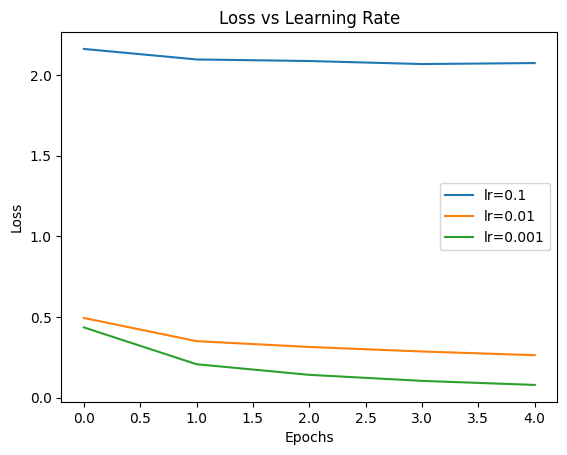

In [12]:
for i, lr in enumerate(learning_rates):
    plt.plot(histories[i].history['loss'], label=f"lr={lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate")
plt.legend()
plt.show()

From the graph, it is evident that a properly chosen learning rate ensures stable convergence, while a very high learning rate leads to divergence.

In [13]:
for lr in learning_rates:
    model = create_model(lr)
    model.fit(x_train, y_train, epochs=5, verbose=0)
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"LR: {lr} → Accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR: 0.1 → Accuracy: 0.15870000422000885


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR: 0.01 → Accuracy: 0.920799970626831


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR: 0.001 → Accuracy: 0.9502000212669373


A high learning rate (0.1) causes large weight updates, leading to overshooting and poor performance.
A moderate learning rate (0.01) balances convergence speed and stability.
A low learning rate (0.001) provides more stable updates and better accuracy, though it may require more epochs.

We observe, the learning rate significantly affects model performance. Lower learning rates improve stability and accuracy, while higher learning rates can prevent proper convergence.

Increasing epochs = 10, the model accuracy goes from 95 to 97%
Adding dropout reduces overfitting.